In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from plot_hourly_energy import (
    plot_hourly_energy,
    plot_hourly_energy_overlay,
    find_runs,
    aggregate_runs,
    plot_cumulative_rewards_multi,
    plot_cumulative_rewards,
    plot_rewards_comparison,
    plot_scenario_metrics_box,
    plot_daily_energy_summary
)

from plot_hourly_energy import plot_hourly_clearing_price


In [2]:
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "legend.fontsize": 10,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.titlesize": 18,   # ← controla suptitle
})

In [3]:
NORM_REWARD_LOCAL_OBS = "../exp_results_repro/final_tesis_norm_reward_local_obs"
NORM_REWARD_PARTIAL_OBS = "../exp_results_repro/final_tesis_norm_reward_partial_obs"
NORM_REWARD_TOTAL_OBS = "../exp_results_repro/final_tesis_norm_reward_total_obs"

GINI_REWARD_LOCAL_OBS = "../exp_results_repro/final_tesis_gini_reward_local_obs"
GINI_REWARD_PARTIAL_OBS = "../exp_results_repro/final_tesis_gini_reward_partial_obs"
GINI_REWARD_TOTAL_OBS = "../exp_results_repro/final_tesis_gini_reward_total_obs"

JAIN_REWARD_LOCAL_OBS = "../exp_results_repro/final_tesis_jain_reward_local_obs"
JAIN_REWARD_PARTIAL_OBS = "../exp_results_repro/final_tesis_jain_reward_partial_obs"
JAIN_REWARD_TOTAL_OBS = "../exp_results_repro/final_tesis_jain_reward_total_obs"

# JAIN_ONLY_REWARD_LOCAL_OBS = "../exp_results_repro/final_tesis_jain_only_reward_local_obs"
# JAIN_ONLY_REWARD_PARTIAL_OBS = "../exp_results_repro/final_tesis_jain_only_reward_partial_obs"
# JAIN_ONLY_REWARD_TOTAL_OBS = "../exp_results_repro/final_tesis_jain_only_reward_total_obs"

JAIN_ONLY_REWARD_LOCAL_OBS = "../exp_results_repro/R3-S3_2"
JAIN_ONLY_REWARD_PARTIAL_OBS = "../exp_results_repro/R3-S2_2"
JAIN_ONLY_REWARD_TOTAL_OBS = "../exp_results_repro/R3-S1_2"

ABS_REWARD_LOCAL_OBS = "../exp_results_repro/final_tesis_abs_reward_local_obs"
ABS_REWARD_PARTIAL_OBS = "../exp_results_repro/final_tesis_abs_reward_partial_obs"
ABS_REWARD_TOTAL_OBS = "../exp_results_repro/final_tesis_abs_reward_total_obs"

# NORM_REWARD_TOTAL_OBS = "../exp_results_repro/desc_pu_gini"

In [4]:
def plot_analysis(exp_path, case, seed=None, ylim=(0,1200)):
    figsize = (10,6)
    if seed is not None:
        title1 = f"Reward comparison - {case}: Best seed {seed}"
        title2 = f"Energy Balance - {case}: Best seed {seed}"
        title3 = f"Prices - {case}: Best seed {seed}"
    else: 
        title1 = f"Reward comparison - {case}: Mean over all seeds"
        title2 = f"Energy Balance - {case}: Mean over all seeds"
        title3 = f"Prices - {case}: Mean over all seeds"
    fig, ax, _ = plot_cumulative_rewards(exp_path, title=title1, figsize=figsize, ylim=ylim, seed=seed)
    df_avg = plot_hourly_energy_overlay(exp_path, title=title2, figsize=figsize, seed=seed)
    df_seed = plot_hourly_clearing_price(
        exp_path, title=title3, figsize=figsize,
        profiles_json_path="../profiles/agents_profiles_24h.json",
        seed=seed,band="minmax", show_volume_prediction=False, show_p2p_volume=False
    )
    plt.show()

# Best Seeds


[Total obs]
        seed    total   jain   gini lossN  score passed
 seed49_run8   2197.8 0.8186 0.2215    0% 0.9483      ✓
 seed50_run9   2107.4 0.7600 0.3095    0% 0.5225      ✓
 seed42_run1   2442.8 0.7068 0.3431    0% 0.3000      ✓
 seed43_run2   1021.2 0.7294 0.3299    0% 0.1230      ✓
 seed44_run3   2570.5 0.5258 0.4643   17%      —      ✗
 seed45_run4    748.2 0.7260 0.3428   33%      —      ✗
 seed46_run5   2122.8 0.4303 0.5647   17%      —      ✗
 seed47_run6    886.5 0.7956 0.2626   17%      —      ✗
 seed48_run7   2078.4 0.4310 0.5653   17%      —      ✗
seed51_run10   2572.3 0.5281 0.4664   17%      —      ✗
  → mejor: seed49_run8  (score=0.9483)

[Partial obs]
        seed    total   jain   gini lossN  score passed
 seed47_run6   2603.0 0.8411 0.2369    0% 0.9833      ✓
 seed50_run9   2511.3 0.8106 0.2555    0% 0.8746      ✓
seed51_run10   2632.4 0.7732 0.2845    0% 0.8693      ✓
 seed44_run3   2223.1 0.6213 0.3943    0% 0.3418      ✓
 seed46_run5   2104.8 0.4824 0.5012  

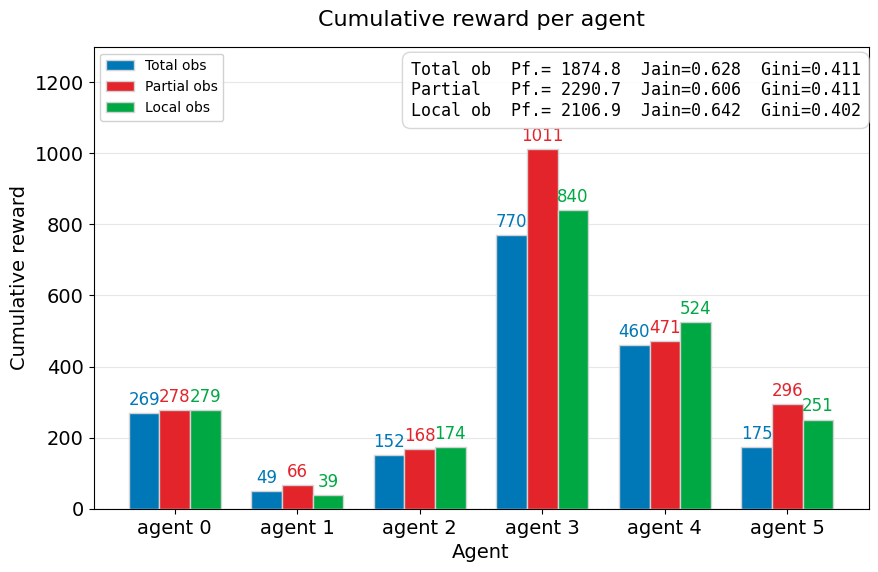

In [5]:
fig, ax, metrics = plot_cumulative_rewards_multi(
    scenario_dirs=[
        NORM_REWARD_TOTAL_OBS,
        NORM_REWARD_PARTIAL_OBS,
        NORM_REWARD_LOCAL_OBS,
    ],
    labels=["Total obs", "Partial obs", "Local obs"],
    ylim=(0, 1300),
    figsize=(10,6)
)

## Gini Reward


[Total obs]
        seed    total   jain   gini lossN  score passed
seed50_run59   2225.5 0.7567 0.3134    0% 0.8683      ✓
seed43_run52   2430.5 0.6666 0.3820    0% 0.7653      ✓
seed49_run58   2108.4 0.6761 0.3105    0% 0.6867      ✓
seed51_run60   2505.7 0.5184 0.4645    0% 0.4980      ✓
seed42_run51   1856.4 0.5437 0.4676    0% 0.2364      ✓
seed48_run57   2043.0 0.4461 0.5706    0% 0.0862      ✓
seed44_run53   2340.3 0.4675 0.5151   17%      —      ✗
seed45_run54    835.4 0.7061 0.3606   33%      —      ✗
seed46_run55   2105.9 0.4265 0.5713   17%      —      ✗
seed47_run56   1999.6 0.6178 0.4125   17%      —      ✗
  → mejor: seed50_run59  (score=0.8683)

[Partial obs]
        seed    total   jain   gini lossN  score passed
seed51_run30   2633.8 0.7845 0.2763    0% 0.9853      ✓
seed43_run22   2518.3 0.7889 0.2722    0% 0.9269      ✓
seed50_run29   2236.0 0.7578 0.3155    0% 0.6245      ✓
seed44_run23   2373.7 0.7131 0.3471    0% 0.5754      ✓
seed45_run24   2632.2 0.6006 0.4104 

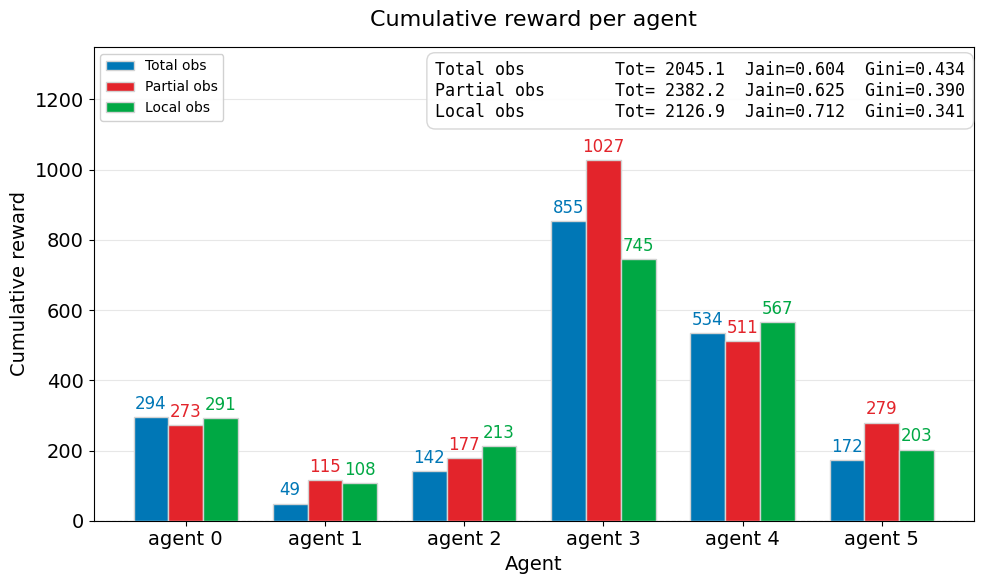

In [ ]:
fig, ax, metrics = plot_cumulative_rewards_multi(
    scenario_dirs=[
        GINI_REWARD_TOTAL_OBS,
        GINI_REWARD_PARTIAL_OBS,
        GINI_REWARD_LOCAL_OBS,
    ],
    labels=["Total obs", "Partial obs", "Local obs"],
    ylim=(0, 1350),
    figsize=(10,6)
)

## JAIN


[Total obs]
        seed    total   jain   gini lossN  score passed
seed50_run49   2190.1 0.7664 0.3043    0% 0.9826      ✓
seed49_run48   2078.2 0.6828 0.2871    0% 0.5108      ✓
seed42_run41   2068.8 0.6106 0.4148    0% 0.1753      ✓
seed48_run47   2122.2 0.5696 0.4854    0% 0.1320      ✓
seed43_run42   1094.3 0.5616 0.4675   17%      —      ✗
seed44_run43   2190.4 0.4607 0.5118   17%      —      ✗
seed45_run44    818.5 0.6994 0.3671   33%      —      ✗
seed46_run45   1754.2 0.4113 0.5773   17%      —      ✗
seed47_run46   1703.4 0.7728 0.2960   17%      —      ✗
seed51_run50   2617.3 0.5215 0.4713   17%      —      ✗
  → mejor: seed50_run49  (score=0.9826)

[Partial obs]
        seed    total   jain   gini lossN  score passed
seed47_run56   2599.6 0.8658 0.2228    0% 0.9942      ✓
seed51_run60   2530.0 0.8526 0.2301    0% 0.9106      ✓
seed43_run52   2516.4 0.7902 0.2737    0% 0.7565      ✓
seed50_run59   2227.0 0.7403 0.3314    0% 0.3922      ✓
seed44_run53   2295.5 0.6757 0.3626 

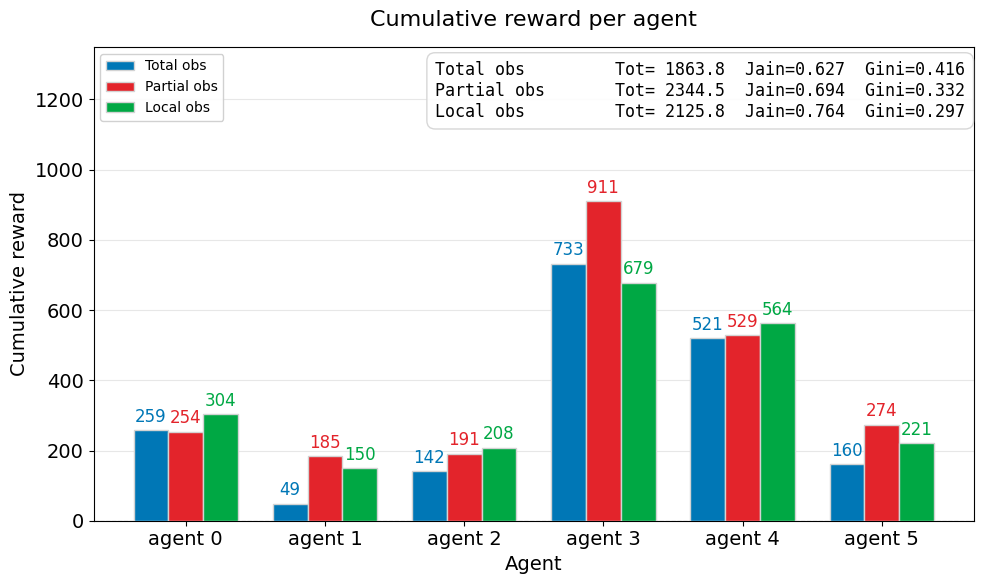

In [ ]:
fig, ax, metrics = plot_cumulative_rewards_multi(
    scenario_dirs=[
        JAIN_REWARD_TOTAL_OBS,
        JAIN_REWARD_PARTIAL_OBS,
        JAIN_REWARD_LOCAL_OBS,
    ],
    labels=["Total obs", "Partial obs", "Local obs"],
    ylim=(0, 1350),
    figsize=(10,6)
)


[Total obs]
        seed    total   jain   gini lossN  score passed
 seed42_run1    -74.4 0.7329 0.3221   50% 0.7000      ✗
 seed43_run2    -74.4 0.7329 0.3221   50% 0.7000      ✗
 seed44_run3    -74.4 0.7329 0.3221   50% 0.7000      ✗
 seed45_run4    -74.4 0.7329 0.3221   50% 0.7000      ✗
 seed47_run6    -74.4 0.7329 0.3221   50% 0.7000      ✗
 seed48_run7    -74.4 0.7329 0.3221   50% 0.7000      ✗
 seed49_run8    -74.4 0.7329 0.3221   50% 0.7000      ✗
seed51_run10    -74.4 0.7329 0.3221   50% 0.7000      ✗
 seed50_run9    -55.8 0.7288 0.3277   50% 0.5311      ✗
 seed46_run5    -48.3 0.7238 0.3293   50% 0.3000      ✗
  ⚠  Ninguna semilla pasó el filtro — ranking sobre pool completo
  → mejor: seed42_run1  (score=0.7000)

[Partial obs]
        seed    total   jain   gini lossN  score passed
seed51_run20   1638.2 0.6786 0.3864    0% 0.7000      ✓
seed43_run12   1693.2 0.5110 0.5175    0% 0.3000      ✓
seed42_run11    -57.4 0.7392 0.3153   50%      —      ✗
seed44_run13    -74.4 0.732

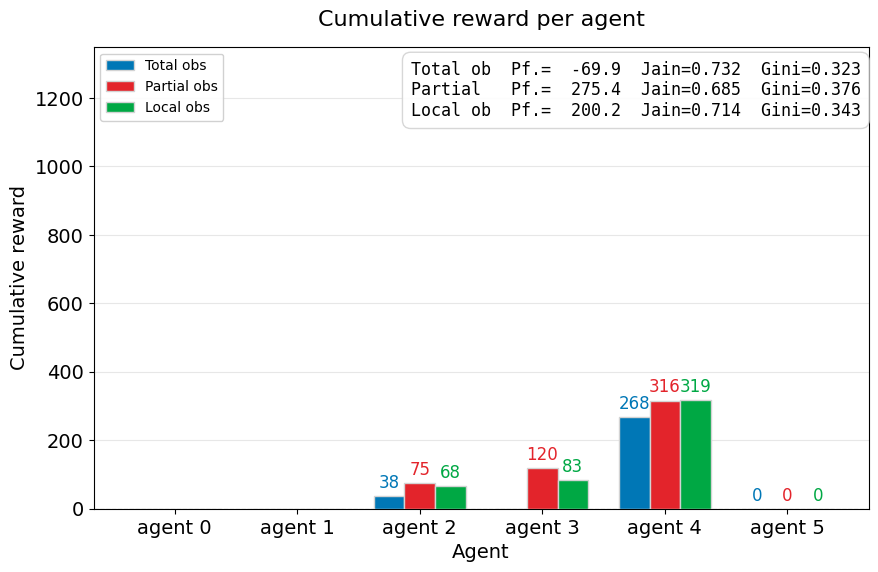

In [5]:
fig, ax, metrics = plot_cumulative_rewards_multi(
    scenario_dirs=[
        JAIN_ONLY_REWARD_TOTAL_OBS,
        JAIN_ONLY_REWARD_PARTIAL_OBS,
        JAIN_ONLY_REWARD_LOCAL_OBS,
    ],
    labels=["Total obs", "Partial obs", "Local obs"],
    ylim=(0, 1350),
    figsize=(10,6)
)

# Resultados Paper

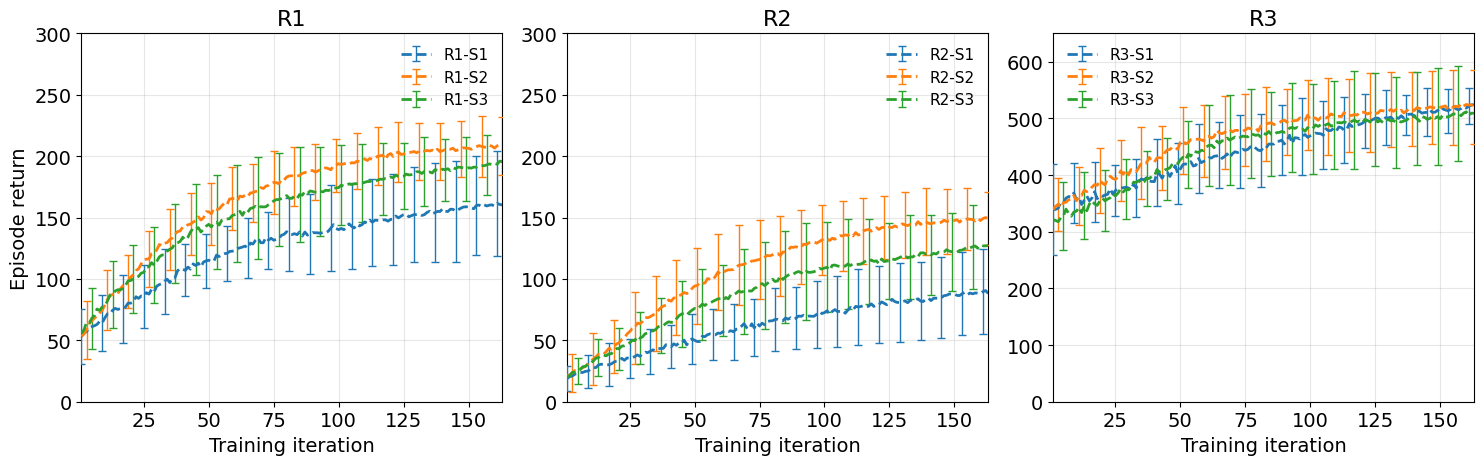

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

y_lim = (0,300)

plot_rewards_comparison(
    scenario_dir=[NORM_REWARD_TOTAL_OBS, NORM_REWARD_PARTIAL_OBS, NORM_REWARD_LOCAL_OBS],
    seed_aggregation="mean",
    labels=["R1-S1", "R1-S2", "R1-S3"],
    title="R1",
    ylim=y_lim,
    ax=axes[0],
    band_style="errorbar",
    error_metric="seed_std",   # dispersión entre semillas
    errorevery=8,
    capsize=3,
    linestyle="--",
    colors=["#1f77b4", "#ff7f0e", "#2ca02c"],
)

plot_rewards_comparison(
    scenario_dir=[JAIN_REWARD_TOTAL_OBS, JAIN_REWARD_PARTIAL_OBS, JAIN_REWARD_LOCAL_OBS],
    seed_aggregation="mean",
    labels=["R2-S1", "R2-S2", "R2-S3"],
    title="R2",
    ylim=y_lim,
    ax=axes[1],        # ← inyectar el eje
    band_style="errorbar",
    error_metric="seed_std",   # dispersión entre semillas
    errorevery=8,
    capsize=3,
    linestyle="--",
    colors=["#1f77b4", "#ff7f0e", "#2ca02c"],
)

plot_rewards_comparison(
    scenario_dir = [JAIN_ONLY_REWARD_TOTAL_OBS, JAIN_ONLY_REWARD_PARTIAL_OBS, JAIN_ONLY_REWARD_LOCAL_OBS],
    seed_aggregation="mean",     # o "envelope"
    labels=["R3-S1", "R3-S2", "R3-S3"],
    title="R3",
    ylim=(0,650),
    ax=axes[2],
    band_style="errorbar",
    error_metric="seed_std",   # dispersión entre semillas
    errorevery=8,
    capsize=3,
    linestyle="--",
    colors=["#1f77b4", "#ff7f0e", "#2ca02c"],
)

# axes[1].get_legend().remove()
axes[1].set_ylabel("")

# axes[2].get_legend().remove()
axes[2].set_ylabel("")
plt.suptitle("")
plt.tight_layout()
plt.show()

fig.savefig("plots/fig_training_courves.pdf", bbox_inches="tight")

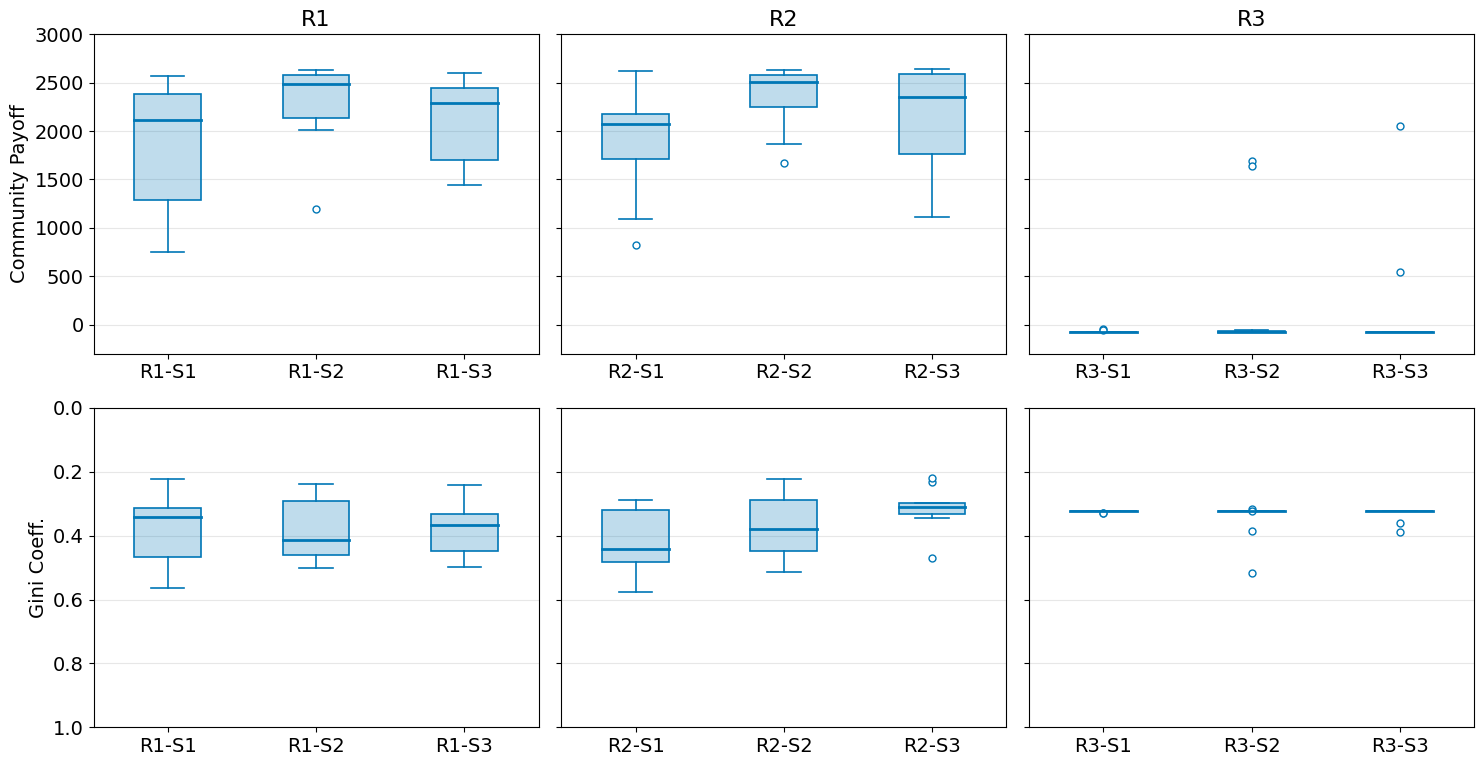

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

ylim_total = (-300,3000)

plot_scenario_metrics_box(
    scenario_dirs=[
        NORM_REWARD_TOTAL_OBS,
        NORM_REWARD_PARTIAL_OBS,
        NORM_REWARD_LOCAL_OBS,
    ],
    labels=["R1-S1", "R1-S2", "R1-S3"],
    title="Scenario comparison Norm. Reward",
    show_points=False,
    ylim_gini=(1,0),
    ylim_jain=(0,1),
    ylim_total=ylim_total,
    ax=axes[:,0]
)

plot_scenario_metrics_box(
    scenario_dirs=[
        JAIN_REWARD_TOTAL_OBS,
        JAIN_REWARD_PARTIAL_OBS,
        JAIN_REWARD_LOCAL_OBS,
    ],
    labels=["R2-S1", "R2-S2", "R2-S3"],
    title="Scenario comparison Jain Index",
    show_points=False,
    ylim_gini=(1,0),
    ylim_jain=(0,1),
    ylim_total=ylim_total,
    ax=axes[:,1]
)

# plot_scenario_metrics_box(
#     scenario_dirs=[
#         GINI_REWARD_TOTAL_OBS,
#         GINI_REWARD_PARTIAL_OBS,
#         GINI_REWARD_LOCAL_OBS,
#     ],
#     labels=["R2-S1", "R2-S2", "R2-S3"],
#     title="Scenario comparison Gini Index",
#     show_points=False,
#     ylim_gini=(1,0),
#     ylim_jain=(0,1),
#     ylim_total=(0,3000),
#     ax=axes[:,1]
# )

plot_scenario_metrics_box(
    scenario_dirs=[
        JAIN_ONLY_REWARD_TOTAL_OBS,
        JAIN_ONLY_REWARD_PARTIAL_OBS,
        JAIN_ONLY_REWARD_LOCAL_OBS,
    ],
    labels=["R3-S1", "R3-S2", "R3-S3"],
    title="Scenario comparison Gini Index",
    show_points=False,
    ylim_gini=(1,0),
    ylim_jain=(0,1),
    ylim_total=ylim_total,
    ax=axes[:,2]
)

axes[0,0].set_title("R1")
axes[0,1].set_title("R2")
axes[0,2].set_title("R3")

# for ax in axes[:-1].flat:
#     ax.set_xticklabels([])

for ax in axes[:,1:].flat:
    ax.set_yticklabels([])
    ax.set_ylabel("")
axes[0,0].set_ylabel("Community Payoff")
plt.suptitle("")
plt.tight_layout()
plt.show()

fig.savefig("plots/fig_multiseed_evaluation.pdf", bbox_inches="tight")

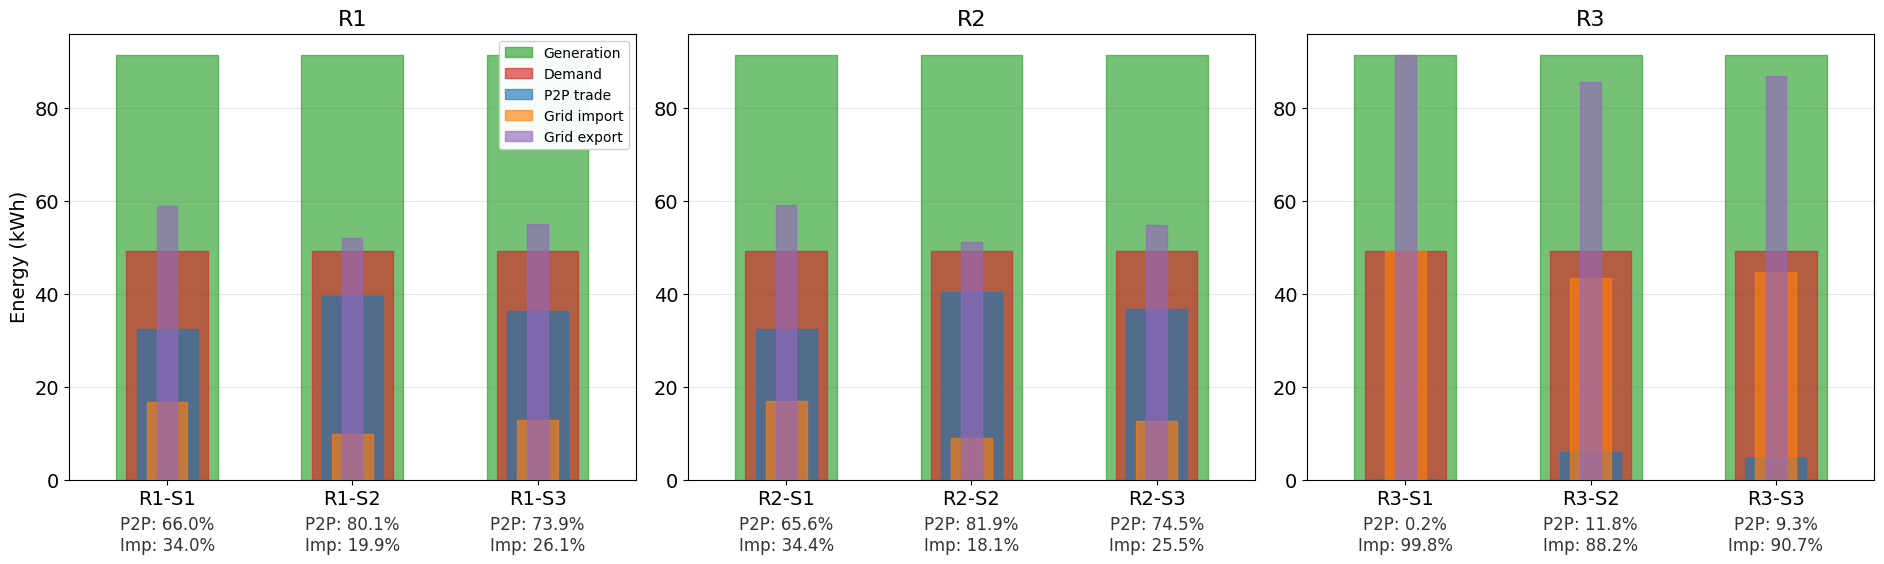

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6))

plot_daily_energy_summary(
    scenario_dirs=[NORM_REWARD_TOTAL_OBS, NORM_REWARD_PARTIAL_OBS, NORM_REWARD_LOCAL_OBS],
    labels=["R1-S1", "R1-S2", "R1-S3"],
    ax=axes[0],
    title="R1",
)
# plot_daily_energy_summary(
#     scenario_dirs=[GINI_REWARD_TOTAL_OBS, GINI_REWARD_PARTIAL_OBS, GINI_REWARD_LOCAL_OBS],
#     labels=["R2-S1", "R2-S2", "R2-S3"],
#     ax=axes[1],
#     title="R2",
# )
plot_daily_energy_summary(
    scenario_dirs=[JAIN_REWARD_TOTAL_OBS, JAIN_REWARD_PARTIAL_OBS, JAIN_REWARD_LOCAL_OBS],
    labels=["R2-S1", "R2-S2", "R2-S3"],
    ax=axes[1],
    title="R2",
)

plot_daily_energy_summary(
    scenario_dirs=[JAIN_ONLY_REWARD_TOTAL_OBS, JAIN_ONLY_REWARD_PARTIAL_OBS, JAIN_ONLY_REWARD_LOCAL_OBS],
    labels=["R3-S1", "R3-S2", "R3-S3"],
    ax=axes[2],
    title="R3",
)

axes[1].set_ylabel("")
axes[2].set_ylabel("")
axes[1].get_legend().remove()
axes[2].get_legend().remove()

fig.suptitle("")
plt.tight_layout()
plt.show()

fig.savefig("plots/fig_energy_summary.pdf", bbox_inches="tight")

\begin{table*}[t]
\centering
\caption{Performance of the nine experimental configurations, reported as mean $\pm$ standard deviation over 10 seeds. Payoff is the community economic payoff; Jain and Gini are performance measures on the realised payoff distribution, distinct from the welfare signals used inside the reward. Best value of each metric in bold.}
\label{tab:factorial_results}
\begin{tabular}{lccccccccc}
\toprule
\textbf{Reward} & \multicolumn{3}{c}{\textbf{S1}} & \multicolumn{3}{c}{\textbf{S2}} & \multicolumn{3}{c}{\textbf{S3}} \\
\cmidrule(lr){2-4}\cmidrule(lr){5-7}\cmidrule(lr){8-10}
 & Payoff & Jain & Gini & Payoff & Jain & Gini & Payoff & Jain & Gini \\
\midrule
\textbf{R1} & 1875 $\pm$ 709 & 0.387 $\pm$ 0.121 & 2291 $\pm$ 444 & 0.381 $\pm$ 0.099 & 2107 $\pm$ 441 & 0.376 $\pm$ 0.088 \\
\textbf{R2} & 1864 $\pm$ 543 & 0.418 $\pm$ 0.101 & \textbf{2344 $\pm$ 334} & 0.369 $\pm$ 0.103 & 2126 $\pm$ 568 & \textbf{0.314 $\pm$ 0.068} \\
\textbf{R3} & -70 $\pm$ 10 & 0.323 $\pm$ 0.00

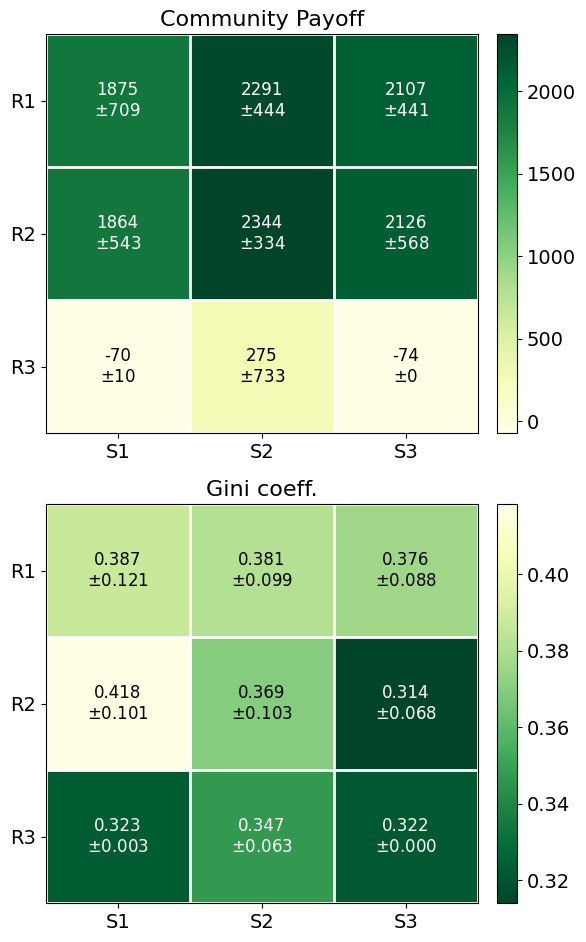

In [12]:
from plot_factorial_summary import (
    collect_factorial_metrics, factorial_table_latex, plot_factorial_heatmap,
)

base = "../exp_results_repro"
dir_grid = {
    ("R1", "S1"): f"{base}/final_tesis_norm_reward_total_obs",
    ("R1", "S2"): f"{base}/final_tesis_norm_reward_partial_obs",
    ("R1", "S3"): f"{base}/final_tesis_norm_reward_local_obs",
    # ("R2", "S1"): f"{base}/final_tesis_gini_reward_total_obs",
    # ("R2", "S2"): f"{base}/final_tesis_gini_reward_partial_obs",
    # ("R2", "S3"): f"{base}/final_tesis_gini_reward_local_obs",
    ("R2", "S1"): f"{base}/final_tesis_jain_reward_total_obs",
    ("R2", "S2"): f"{base}/final_tesis_jain_reward_partial_obs",
    ("R2", "S3"): f"{base}/final_tesis_jain_reward_local_obs",
    ("R3", "S1"): f"{base}/final_tesis_jain_only_reward_total_obs",
    ("R3", "S2"): f"{base}/final_tesis_jain_only_reward_partial_obs",
    ("R3", "S3"): f"{base}/final_tesis_jain_only_reward_local_obs",
}

cell_stats = collect_factorial_metrics(dir_grid)

# Tabla LaTeX (imprime el bloque listo para pegar; pásale p2p_share si lo tienes):
print(factorial_table_latex(cell_stats))

# Heatmap:
fig, axes = plot_factorial_heatmap(cell_stats, figsize=(6,10))
fig.suptitle("")
fig.savefig("plots/fig_factorial_heatmap.pdf", bbox_inches="tight")

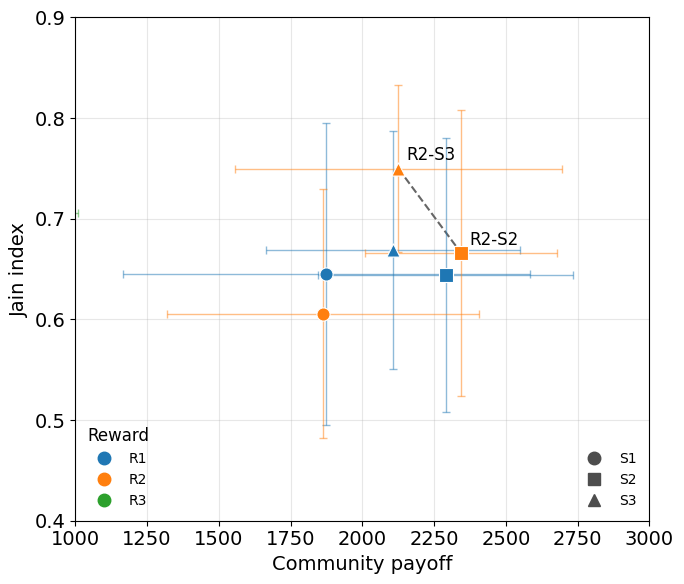

In [6]:
from plot_factorial_summary import plot_tradeoff_scatter

from plot_factorial_summary import (
    collect_factorial_metrics, factorial_table_latex, plot_factorial_heatmap,
)

base = "../exp_results_repro"
dir_grid = {
    ("R1", "S1"): f"{base}/final_tesis_norm_reward_total_obs",
    ("R1", "S2"): f"{base}/final_tesis_norm_reward_partial_obs",
    ("R1", "S3"): f"{base}/final_tesis_norm_reward_local_obs",
    # ("R2", "S1"): f"{base}/final_tesis_gini_reward_total_obs",
    # ("R2", "S2"): f"{base}/final_tesis_gini_reward_partial_obs",
    # ("R2", "S3"): f"{base}/final_tesis_gini_reward_local_obs",
    ("R2", "S1"): f"{base}/final_tesis_jain_reward_total_obs",
    ("R2", "S2"): f"{base}/final_tesis_jain_reward_partial_obs",
    ("R2", "S3"): f"{base}/final_tesis_jain_reward_local_obs",
    ("R3", "S1"): f"{base}/final_tesis_jain_only_reward_total_obs",
    ("R3", "S2"): f"{base}/final_tesis_jain_only_reward_partial_obs",
    ("R3", "S3"): f"{base}/final_tesis_jain_only_reward_local_obs",
}

cell_stats = collect_factorial_metrics(dir_grid)

# Una sola métrica de equidad:
fig, ax = plot_tradeoff_scatter(cell_stats, equity="jain", ylim=(0.4,0.9), xlim=(1000,3000))
fig.savefig("plots/fig_tradeoff_jain.pdf", bbox_inches="tight")

# # O las dos lado a lado:
# import matplotlib.pyplot as plt
# fig, axes = plt.subplots(1, 2, figsize=(13, 6))
# plot_tradeoff_scatter(cell_stats, equity="jain", ax=axes[0], ylim=(0,1))
# plot_tradeoff_scatter(cell_stats, equity="gini", ax=axes[1])
# fig.tight_layout()
# fig.savefig("plots/fig_tradeoff.pdf", bbox_inches="tight")

In [14]:
dir_grid = {
    ("R1", "S1"): f"{base}/R1-S1",
    ("R1", "S2"): f"{base}/R1-S2",
    ("R1", "S3"): f"{base}/R1-S3",
    # ("R2", "S1"): f"{base}/final_tesis_gini_reward_total_obs",
    # ("R2", "S2"): f"{base}/final_tesis_gini_reward_partial_obs",
    # ("R2", "S3"): f"{base}/final_tesis_gini_reward_local_obs",
    ("R2", "S1"): f"{base}/R2-S1",
    ("R2", "S2"): f"{base}/R2-S2",
    ("R2", "S3"): f"{base}/R2-S3",
    ("R3", "S1"): f"{base}/R3-S1",
    ("R3", "S2"): f"{base}/R3-S2",
    ("R3", "S3"): f"{base}/R3-S3",
}
cell_stats = collect_factorial_metrics(dir_grid)

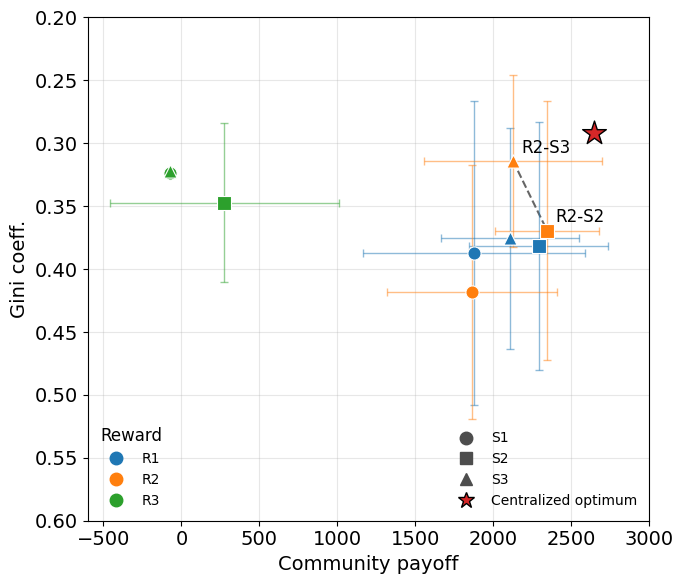

In [10]:
from plot_factorial_summary import baseline_point, plot_tradeoff_scatter

baselines = {
    "Centralized optimum": baseline_point(f"../exp_results_repro/centralized_exp/centralized_midpoint/evaluation_agent_states.csv"),
    # "Midpoint heuristic":  baseline_point(f"../exp_results_repro/heuristic_midpoint/heuristic_midpoint/evaluation_agent_states.csv"),
}
fig, ax = plot_tradeoff_scatter(
    cell_stats, equity="gini", baselines=baselines,
    xlim=(-600, 3000), ylim=(0.6, 0.2),
)
fig.savefig("plots/fig_tradeoff_baselines.pdf", bbox_inches="tight")

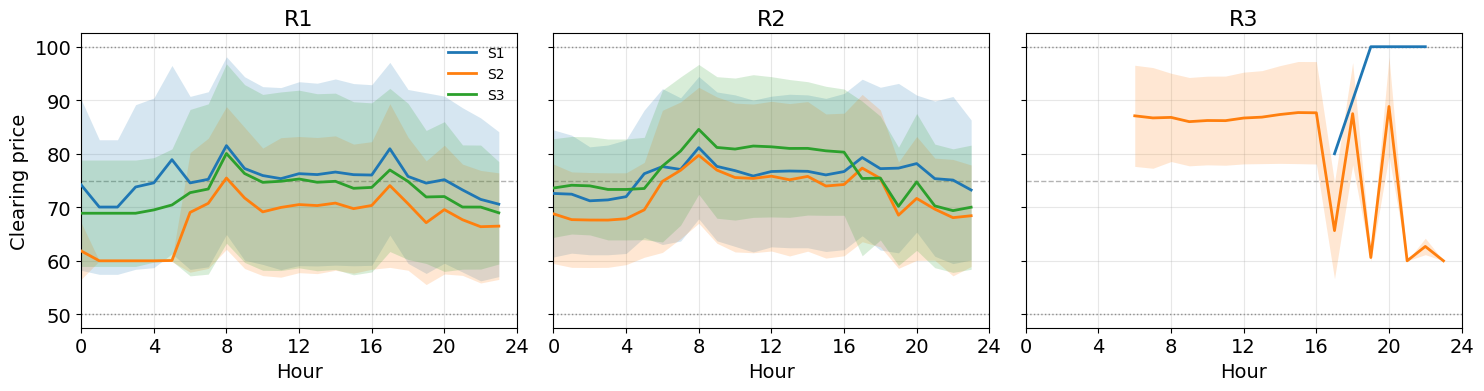

In [11]:
from plot_factorial_summary import plot_clearing_price_grid

fig, ax = plot_clearing_price_grid(
    dir_grid,                                  # el (reward, scenario) -> dir que ya tienes
    profiles_json_path="../profiles/agents_profiles_24h.json",
    lambda_sell=50.0, lambda_buy=100.0,
)
fig.suptitle("")
fig.savefig("plots/fig_clearing_price.pdf", bbox_inches="tight")

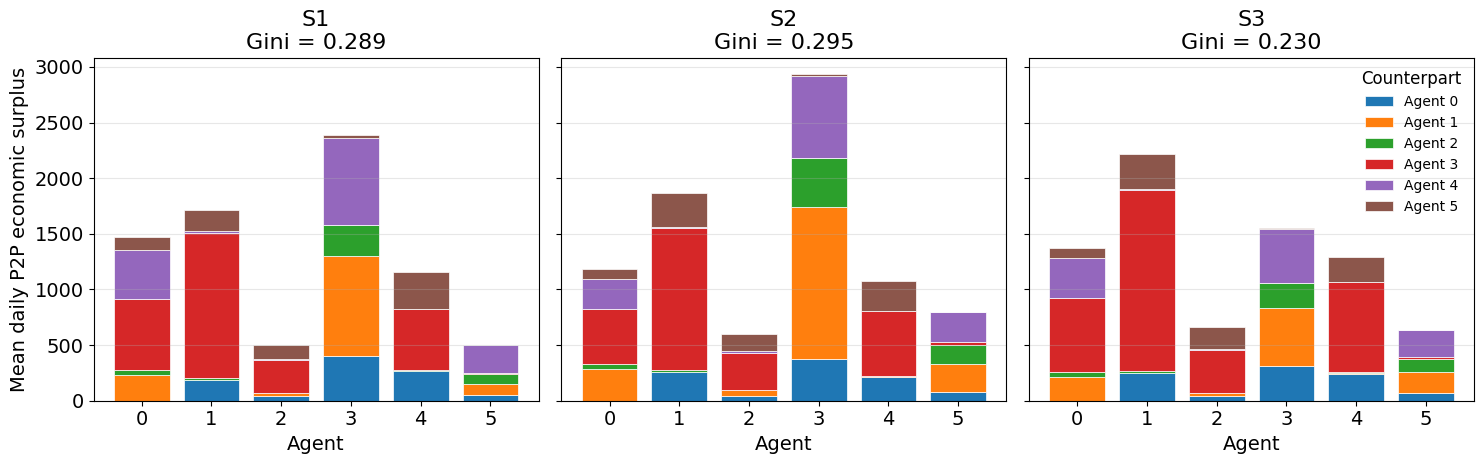

In [19]:
from plot_factorial_summary import plot_agent_surplus

base = "../exp_results_repro"

flow_grid = {
    "S1": f"{base}/R2-S1",
    "S2": f"{base}/R2-S2",
    "S3": f"{base}/R2-S3",
}

fig, ax = plot_agent_surplus(
    flow_grid, lambda_sell=50.0, lambda_buy=100.0,
    # title="Per-agent P2P surplus, stacked by counterpart — R3 Jain",
)
fig.savefig("plots/fig_agent_surplus.pdf", bbox_inches="tight")

# TSNE

In [17]:
from tsne_policies import PolicyTSNE

## R1

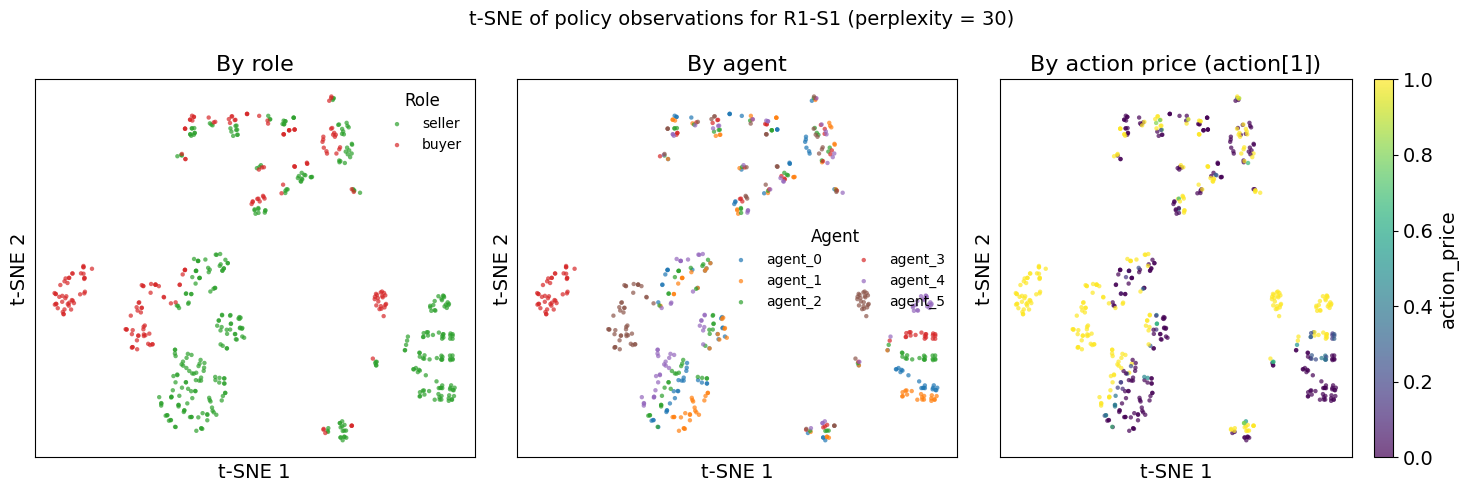

In [23]:
an = PolicyTSNE.from_cache(
    "../exp_results_repro/final_tesis_norm_reward_total_obs/"
    "energy_market_training_norm_total_obs_seed49_run8/PPO_energy_market_run/tsne_analysis"
)

fig = an.panel(perplexity=30, figsize=(15,5), case='R1-S1')

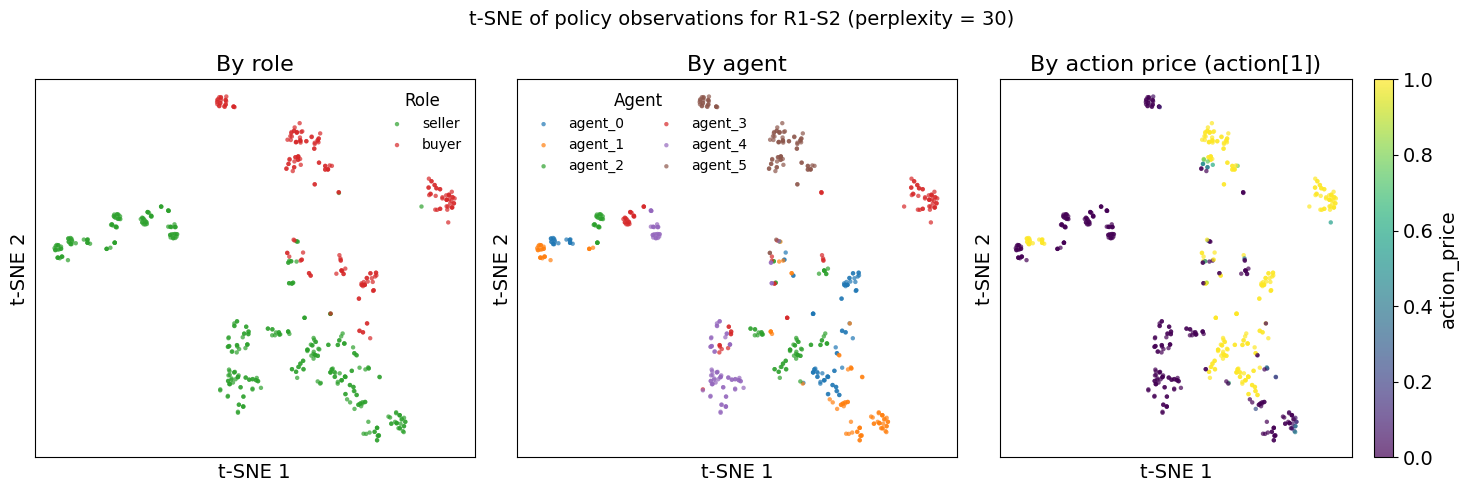

In [20]:
an = PolicyTSNE.from_cache(
    "../exp_results_repro/final_tesis_norm_reward_partial_obs/"
    "energy_market_training_norm_partial_obs_seed47_run6/PPO_energy_market_run/tsne_analysis"
)

fig = an.panel(perplexity=30, figsize=(15,5), case='R1-S2')

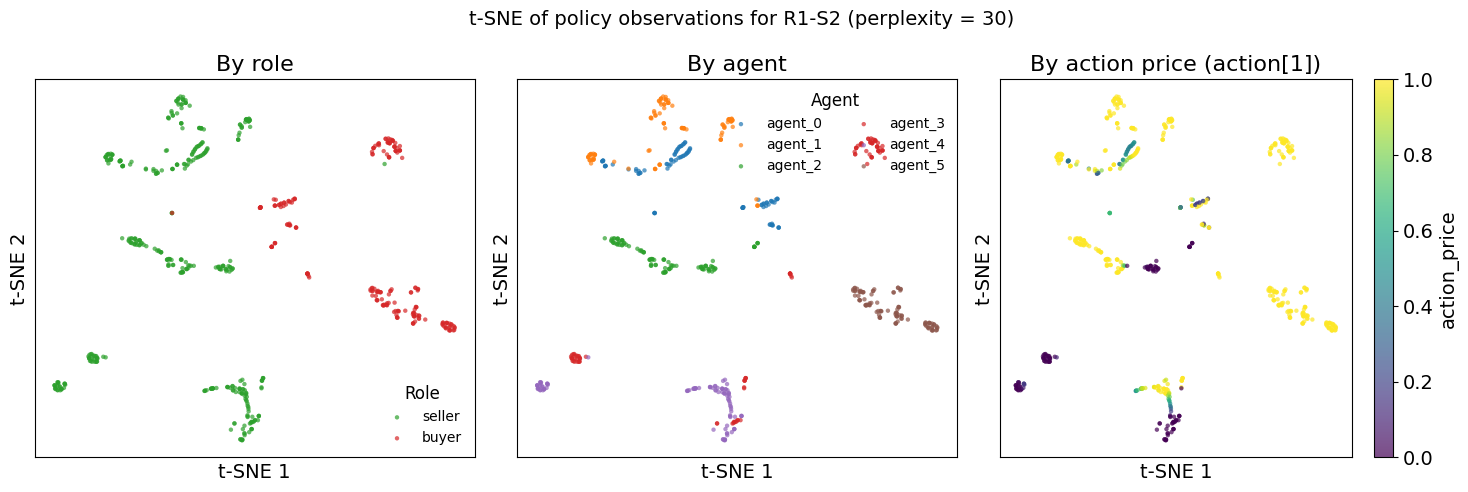

In [21]:
an = PolicyTSNE.from_cache(
    "../exp_results_repro/final_tesis_norm_reward_local_obs/"
    "energy_market_training_norm_local_obs_seed42_run11/PPO_energy_market_run/tsne_analysis"
)

fig = an.panel(perplexity=30, figsize=(15,5), case='R1-S2')

## R2

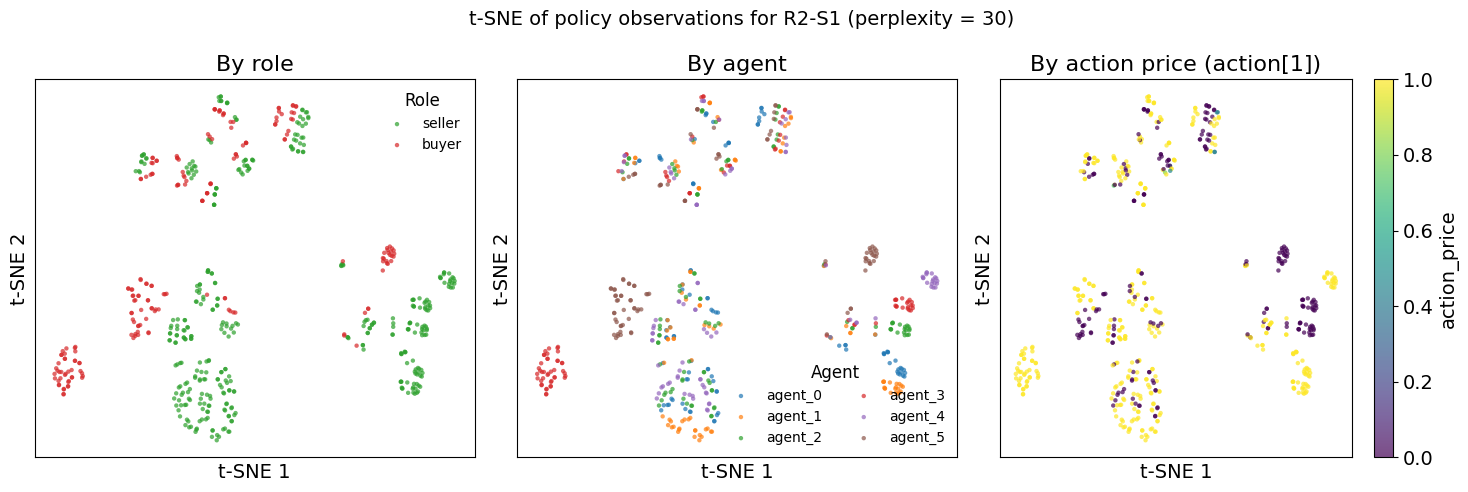

In [24]:
# exp_results_repro/final_tesis_jain_reward_local_obs/energy_market_training_jain_local_obs_seed42_run61/PPO_energy_market_run/tsne_analysis

an = PolicyTSNE.from_cache(
    "../exp_results_repro/final_tesis_jain_reward_total_obs/"
    "energy_market_training_jain_total_obs_seed50_run49/PPO_energy_market_run/tsne_analysis"
)

fig = an.panel(perplexity=30, figsize=(15,5), case='R2-S1')      # panel de 4 vistas, inline
# an.sweep([5, 30, 50])        # barrido de robustez
# an.plot(color_by="action_price", perplexity=50)

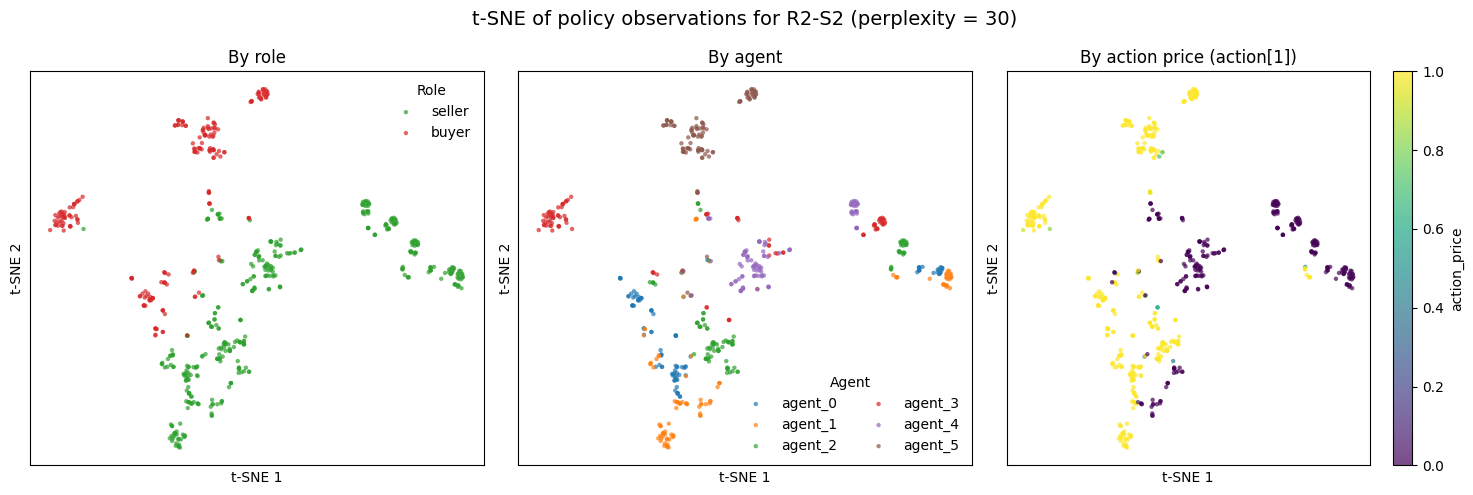

In [8]:
an = PolicyTSNE.from_cache(
    "../exp_results_repro/final_tesis_jain_reward_partial_obs/"
    "energy_market_training_jain_partial_obs_seed47_run56/PPO_energy_market_run/tsne_analysis"
)

fig = an.panel(perplexity=30, figsize=(15,5), case='R2-S2')      # panel de 4 vistas, inline

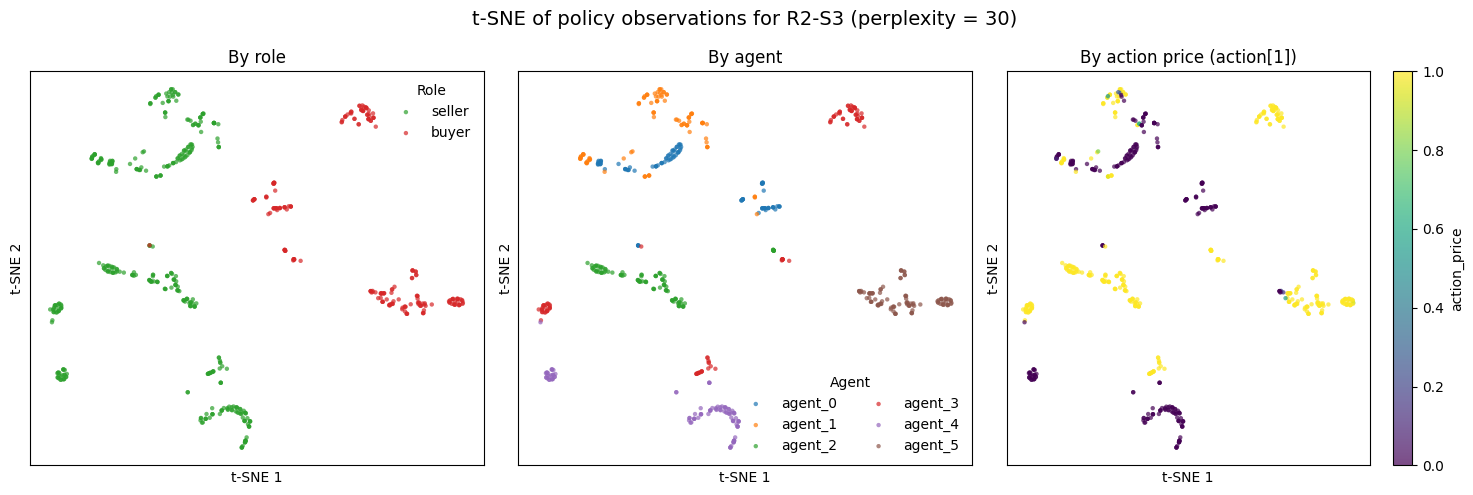

In [10]:
an = PolicyTSNE.from_cache(
    "../exp_results_repro/final_tesis_jain_reward_local_obs/"
    "energy_market_training_jain_local_obs_seed50_run69/PPO_energy_market_run/tsne_analysis"
)

fig = an.panel(perplexity=30, figsize=(15,5), case='R2-S3')  

## R3

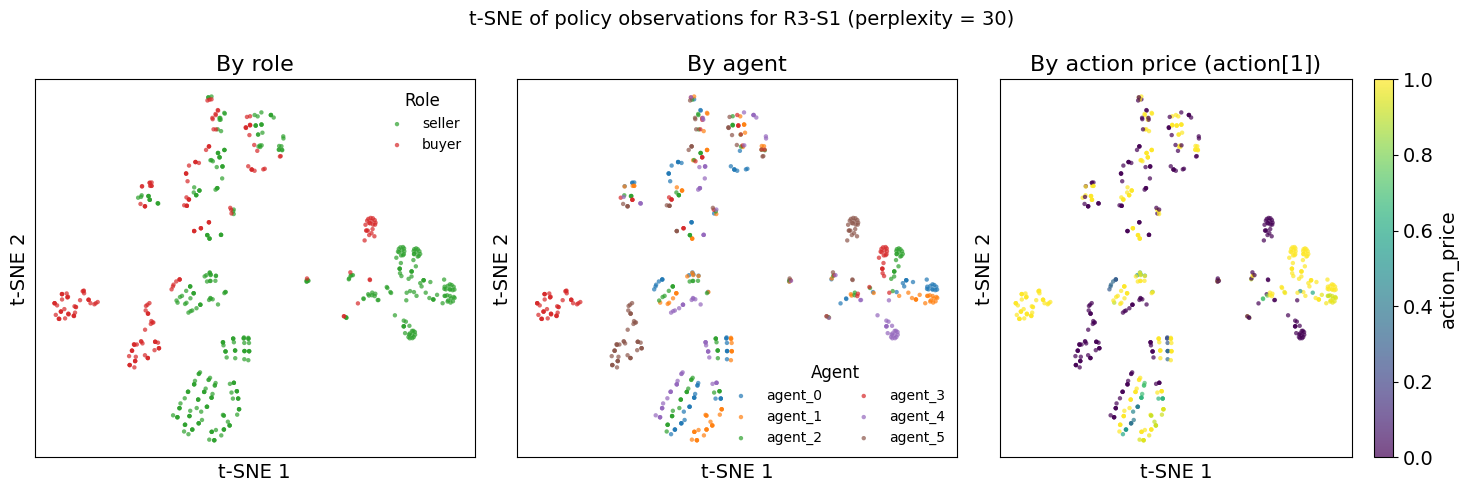

In [8]:
an = PolicyTSNE.from_cache(
    "../exp_results_repro/R3-S1/"
    "energy_market_training_R3-S1_seed48_run67/PPO_energy_market_run/tsne_analysis"
)

fig = an.panel(perplexity=30, figsize=(15,5), case='R3-S1')

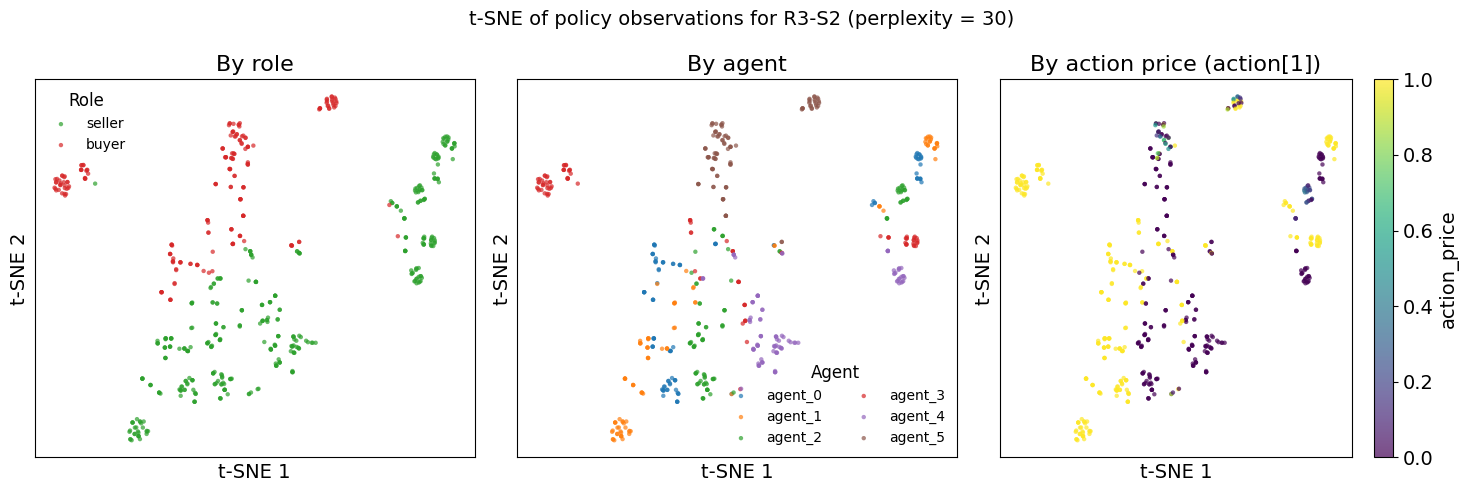

In [9]:
an = PolicyTSNE.from_cache(
    "../exp_results_repro/R3-S2/"
    "energy_market_training_R3-S2_seed51_run80/PPO_energy_market_run/tsne_analysis"
)

fig = an.panel(perplexity=30, figsize=(15,5), case='R3-S2')

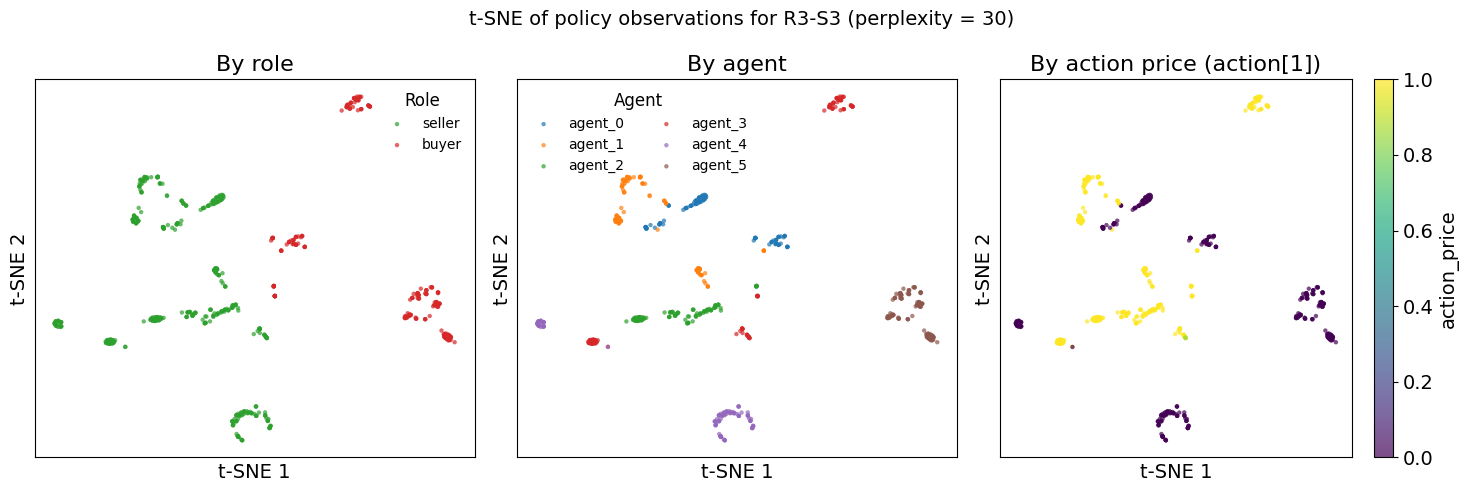

In [27]:
an = PolicyTSNE.from_cache(
    "../exp_results_repro/R3-S3_2/"
    "energy_market_training_R3-S3_seed50_run29/PPO_energy_market_run/tsne_analysis"
)

fig = an.panel(perplexity=30, figsize=(15,5), case='R3-S3')